In [23]:
# =================================
# 設定
# =================================
IS_ONLINE_JUDGE = False

LIMIT_QUERY_CNT = None

DEBUG = False
DEBUG_QUERY = None
DEBUG_L = None

MAX_TIME = 1.25
FILE_NUM = 100

# =================================
# 初期化
# =================================
import time

GLOBAL_START_TIME = time.perf_counter()

import random

random.seed(1111)

if IS_ONLINE_JUDGE:
    DEBUG = False

# =================================
# Import
# =================================
import math
from collections import defaultdict

# =================================
# 共通
# =================================
if True:
    from importlib import reload

    import src.common as common

    reload(common)


from src.common import (
    Env,
    EnvOffline,
    calc_dist,
    calc_rectangle_area,
    construct_dist_matrix,
    construct_graph,
    construct_graph_from_edges,
    cut_graph,
    exponential_schedule,
    prim_k,
    sort_pair,
)


# =================================
# 汎用（main.py専用）
# =================================
def debug_print(*args, **kwargs):
    if IS_ONLINE_JUDGE:
        return
    print(*args, **kwargs)


def print_elapsed_time():
    debug_print(f"elapsed time: {(time.perf_counter() - GLOBAL_START_TIME) * 1000:.2f}msecs")

In [24]:
def cost_formula(d1: int, d2: int) -> int:
    if d1 > d2:
        return d1 - d2
    else:
        return 0


def calc_init_cost(
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    x: list[tuple[int, int]],
) -> tuple[list[int], int]:
    cost_list: list[int] = [0 for _ in range(len(constrains))]
    for ci in range(len(constrains)):
        cons = constrains[ci]
        (p1, p2), (q1, q2) = cons
        dist1 = calc_dist(x[p1], x[p2])
        dist2 = calc_dist(x[q1], x[q2])
        cost_list[ci] = cost_formula(dist1, dist2)
    total_cost = sum(cost_list)
    return cost_list, total_cost


def calc_cost(
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    x_now: list[tuple[int, int]],
    x_update: dict[int, tuple[int, int]],
    cost_list: list[int],
    cost_now: int,
    vid_to_constid: dict[int, list[int]],
) -> tuple[dict[int, int], int]:
    new_cost = cost_now
    cost_update = dict()
    for v in x_update:
        for consid in vid_to_constid[v]:
            (p1, p2), (q1, q2) = constrains[consid]
            coord1 = x_update[p1] if p1 in x_update else x_now[p1]
            coord2 = x_update[p2] if p2 in x_update else x_now[p2]
            coord3 = x_update[q1] if q1 in x_update else x_now[q1]
            coord4 = x_update[q2] if q2 in x_update else x_now[q2]
            dist1 = calc_dist(coord1, coord2)
            dist2 = calc_dist(coord3, coord4)
            pre_cost = cost_list[consid]
            now_cost = cost_formula(dist1, dist2)
            new_cost += now_cost - pre_cost
            cost_update[consid] = now_cost
    return cost_update, new_cost


def neighbor(
    x: list[tuple[int, int]],
    target_v: list[int],
    rects: list[list[int]],
    now_mul_x: float,
    k: int = 1,
):
    vs: list[int] = random.sample(target_v, k=k)
    x_update: dict[int, tuple[int, int]] = dict()

    for v in vs:
        rnd = random.random()
        rand_coord = tuple()
        if rnd < 0.99:
            x1, x2, y1, y2 = rects[v]
            nx, ny = x[v]
            dx = x2 - x1
            dy = y2 - y1
            max_dx = max(int(dx * now_mul_x), 1)
            max_dy = max(int(dy * now_mul_x), 1)
            lim_l = max(x1, nx - max_dx)
            lim_r = min(x2, nx + max_dx)
            lim_u = max(y1, ny - max_dy)
            lim_d = min(y2, ny + max_dy)
            rand_coord = random.randint(lim_l, lim_r), random.randint(lim_u, lim_d)
        else:
            x1, x2, y1, y2 = rects[v]
            rand_coord = random.randint(x1, x2), random.randint(y1, y2)

        x_update[v] = rand_coord
        nx, ny = x[v]
        x1, x2, y1, y2 = rects[v]
        if (x2 - x1) == 0:
            mul_x = 0.01
        else:
            mul_x = abs(nx - rand_coord[0]) / (x2 - x1)

    return x_update, mul_x

In [25]:
def simulated_annealing(
    x0: list[tuple[int, int]],
    t0: float,
    t1: float,
    constrains: list[tuple[tuple[int, int], tuple[int, int]]],
    rectangles: list[tuple[int, int, int, int]],
    target_vs: list[int],
    vid_to_constid: dict[int, list[int]],
    max_time: float = 1.0,
    display: bool = False,
):
    x = x0.copy()
    x_best = x
    x_update = dict()

    cost_list, cost_current = calc_init_cost(constrains, x)
    cost_best = cost_current
    cost_update = dict()

    simulate_cnt = 0
    good_cnt = 0
    st = time.perf_counter()

    sum_mul_x = 0.0
    now_mul_x = 0.5
    while True:
        elapsed_time = time.perf_counter() - st
        if elapsed_time >= max_time:
            break
        temp = exponential_schedule(t0, t1, elapsed_time, max_time)

        x_update, mul_x = neighbor(x, target_vs, rectangles, now_mul_x)
        cost_update, cost_new = calc_cost(
            constrains=constrains,
            x_now=x,
            x_update=x_update,
            cost_list=cost_list,
            cost_now=cost_current,
            vid_to_constid=vid_to_constid,
        )

        delta_cost = cost_new - cost_current
        if delta_cost < 0:
            good_cnt += 1
            sum_mul_x += mul_x
        if delta_cost <= 0 or random.random() < math.exp(-delta_cost / temp):
            cost_current = cost_new
            for v in x_update:
                x[v] = x_update[v]
            for ci in cost_update:
                cost_list[ci] = cost_update[ci]
        if cost_current < cost_best:
            x_best = x
            cost_best = cost_current

        simulate_cnt += 1
        if display and simulate_cnt % 5000 == 0:
            debug_print(
                f"i: {simulate_cnt}, cost_now: {cost_current}, best_cost: {cost_best}, temp: {temp:.2f}, good_cnt: {good_cnt}/{simulate_cnt}"
            )
        if good_cnt > 0 and good_cnt % 100 == 0:
            now_mul_x = max(min(0.01, sum_mul_x / good_cnt), 0.5)
            sum_mul_x = 0.0
    return x_best, cost_best

In [ ]:
import itertools
import math


def calc_triangle_score(p1: tuple[int, int], p2: tuple[int, int], p3: tuple[int, int]) -> float:
    """三角形が正三角形にどれだけ近いか（辺の長さの標準偏差で評価）"""
    d1 = math.dist(p1, p2)
    d2 = math.dist(p2, p3)
    d3 = math.dist(p3, p1)
    mean = (d1 + d2 + d3) / 3
    variance = ((d1 - mean) ** 2 + (d2 - mean) ** 2 + (d3 - mean) ** 2) / 3
    return math.sqrt(variance)

In [ ]:
def is_point_in_polygon(polygon: list[tuple[int, int]], coord: list[tuple[int, int]]) -> bool:
    x, y = coord

    is_inside = False
    n = len(polygon)
    px, py = x, y

    for i in range(n):
        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]

        if min(y1, y2) < py <= max(y1, y2):
            x_intersect = (py - y1) * (x2 - x1) / (y2 - y1 + 1e-10) + x1
            if px < x_intersect:
                is_inside = not is_inside

    return is_inside

In [28]:
def _orientation(
    p: tuple[int, int],
    q: tuple[int, int],
    r: tuple[int, int],
) -> int:
    """p, q, r の向きを返す。
    0 -> colinear（一直線）
    1 -> clockwise（時計回り）
    2 -> counterclockwise（反時計回り）
    """
    val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
    if abs(val) < 1e-10:
        return 0
    return 1 if val > 0 else 2


def _on_segment(
    p: tuple[int, int],
    q: tuple[int, int],
    r: tuple[int, int],
) -> bool:
    """点qが線分pr上にあるか"""
    return min(p[0], r[0]) <= q[0] <= max(p[0], r[0]) and min(p[1], r[1]) <= q[1] <= max(p[1], r[1])


def do_intersect(
    s1: tuple[tuple[int, int], tuple[int, int]],
    s2: tuple[tuple[int, int], tuple[int, int]],
) -> bool:
    p1, q1 = s1
    p2, q2 = s2

    shared_points = {p1, q1} & {p2, q2}
    if len(shared_points) == 1:
        return False

    o1 = _orientation(p1, q1, p2)
    o2 = _orientation(p1, q1, q2)
    o3 = _orientation(p2, q2, p1)
    o4 = _orientation(p2, q2, q1)

    # 一般ケース
    if o1 != o2 and o3 != o4:
        return True

    # 特殊ケース（一直線上にある場合）
    if o1 == 0 and _on_segment(p1, p2, q1):
        return True
    if o2 == 0 and _on_segment(p1, q2, q1):
        return True
    if o3 == 0 and _on_segment(p2, p1, q2):
        return True
    if o4 == 0 and _on_segment(p2, q1, q2):
        return True

    return False


def any_intersection(
    polygon: list[tuple[int, int]],
    target_edge: tuple[tuple[int, int], tuple[int, int]],
) -> bool:
    edges = [(polygon[i], polygon[(i + 1) % len(polygon)]) for i in range(len(polygon))]
    for edge in edges:
        if do_intersect(edge, target_edge):
            return True
    return False

In [ ]:
def construct_triangle(env: Env, random_v: int, all_graph: dict[int, list[tuple[int, int]]]):
    neighbors: list[int, int] = all_graph[random_v]
    neighbor_v_nums: list[int] = [v for d, v in neighbors][:10]
    v1 = random.choice(neighbor_v_nums)

    best_score = float("inf")
    now_p: tuple[int, int] = env.cneter_points[random_v]
    for v2 in neighbor_v_nums:
        if v2 == v1:
            continue
        p1 = env.cneter_points[v1]
        p2 = env.cneter_points[v2]
        t_score = calc_triangle_score(now_p, p1, p2)
        if t_score < best_score:
            best_score = t_score
            best_triangle = (random_v, v1, v2)
            best_triangle_points = (now_p, p1, p2)

    polygon_vs: list[int] = list(best_triangle)
    polygon_coords: list[tuple[int, int]] = list(best_triangle_points)
    return polygon_vs, polygon_coords


def construct_droneyard(env: Env, polygon_vs: list[int], polygon_coords: list[tuple[int, int]]):
    ret_polygon_vs = polygon_vs.copy()
    ret_polygon_coords = polygon_coords.copy()

    ok_vs: list[int] = set(list(range(env.N))) - set(polygon_vs)
    for _ in range(env.L - 3):
        next_vs = []
        no_vs = set()
        for v in ok_vs:
            if is_point_in_polygon(ret_polygon_coords, env.cneter_points[v]):
                no_vs.add(v)
            else:
                next_vs.append(v)
        ok_vs -= no_vs

        now_polygon_num = len(ret_polygon_coords)
        rand_polygon_inds = list(range(now_polygon_num))
        random.shuffle(rand_polygon_inds)

        add_v = -1
        add_ind = -1
        for polygon_i in rand_polygon_inds:
            memos = []
            for next_v in next_vs:
                p1 = ret_polygon_coords[polygon_i]
                p2 = ret_polygon_coords[(polygon_i + 1) % len(ret_polygon_coords)]
                target_p = env.cneter_points[next_v]
                if any_intersection(ret_polygon_coords, (p1, target_p)) or any_intersection(
                    ret_polygon_coords, (p2, target_p)
                ):
                    continue
                t_cost = calc_triangle_score(p1, p2, target_p)
                memos.append((t_cost, next_v, polygon_i))
            if len(memos) == 0:
                continue
            memos.sort(key=lambda x: x[0])
            _, add_v, add_ind = memos[0]

        ret_polygon_vs.insert(add_ind + 1, add_v)
        ret_polygon_coords.insert(add_ind + 1, env.cneter_points[add_v])
        ok_vs -= {add_v}
    return ret_polygon_vs, ret_polygon_coords

In [30]:
file_num = 62
input_file_path = f"../in/{file_num:04d}.txt"
output_file_path = f"../out/{file_num:04d}.txt"
env = EnvOffline(input_file_path, output_file_path)

In [31]:
all_graph: dict[int, list[tuple[int, int]]] = construct_graph({i: p for i, p in enumerate(env.cneter_points)})
graph_matrix = construct_dist_matrix(env.cneter_points)

In [ ]:
area_list = []
for polygon_i, (l, r, t, b) in enumerate(env.rectangles):
    dx = r - l
    dy = b - t
    area_list.append((polygon_i, dx * dy))
area_list.sort(key=lambda x: x[1], reverse=True)
area_points = [i for i, _ in area_list]

target_query = []
for q in range(400):
    target_v = area_points[q]
    polygon_vs, polygon_coords = construct_triangle(env, target_v, all_graph)
    polygon_vs, _ = construct_droneyard(env, polygon_vs, polygon_coords)
    target_query.append(polygon_vs)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [33]:
constrains = set()
target_vs = set()
for query_v in target_query:
    target_vs |= set(list(query_v))
    edges = env.query(query_v)
    graph = construct_graph_from_edges(edges, query_v)
    for e in edges:
        group_vs1, group_vs2 = cut_graph(graph, e)
        for v1 in group_vs1:
            for v2 in group_vs2:
                sv1, sv2 = sort_pair((v1, v2))
                if e == (sv1, sv2):
                    continue
                # if (e, (sv1, sv2)) in constrains:
                #     print("重複")
                constrains.add((e, (sv1, sv2)))

constrains = list(constrains)
target_vs = list(target_vs)

In [34]:
print(len(target_query), len(target_vs), len(constrains), len(constrains) / len(target_query))

400 795 117167 292.9175


In [35]:
vid_to_constid = defaultdict(set)
for polygon_i, const in enumerate(constrains):
    (p1, p2), (q1, q2) = const
    vid_to_constid[p1].add(polygon_i)
    vid_to_constid[p2].add(polygon_i)
    vid_to_constid[q1].add(polygon_i)
    vid_to_constid[q2].add(polygon_i)

In [36]:
x_bests = []
for _ in range(1):
    x_best, cost_best = simulated_annealing(
        x0=env.cneter_points,
        t0=10.0,
        t1=1.0,
        constrains=constrains,
        rectangles=env.rectangles,
        target_vs=target_vs,
        vid_to_constid=vid_to_constid,
        max_time=100,
        display=True,
    )
    x_bests.append(x_best)

i: 5000, cost_now: 940904, best_cost: 940904, temp: 9.50, good_cnt: 1239/5000
i: 10000, cost_now: 307786, best_cost: 307786, temp: 9.04, good_cnt: 1968/10000
i: 15000, cost_now: 149270, best_cost: 149262, temp: 8.61, good_cnt: 2457/15000
i: 20000, cost_now: 89792, best_cost: 89792, temp: 8.21, good_cnt: 2835/20000
i: 25000, cost_now: 58799, best_cost: 58765, temp: 7.82, good_cnt: 3112/25000
i: 30000, cost_now: 43538, best_cost: 43538, temp: 7.47, good_cnt: 3354/30000
i: 35000, cost_now: 31960, best_cost: 31942, temp: 7.14, good_cnt: 3577/35000
i: 40000, cost_now: 27880, best_cost: 27880, temp: 6.81, good_cnt: 3749/40000
i: 45000, cost_now: 23943, best_cost: 23943, temp: 6.51, good_cnt: 3916/45000
i: 50000, cost_now: 20488, best_cost: 20465, temp: 6.20, good_cnt: 4038/50000
i: 55000, cost_now: 16538, best_cost: 16527, temp: 5.92, good_cnt: 4190/55000
i: 60000, cost_now: 15239, best_cost: 15231, temp: 5.63, good_cnt: 4325/60000
i: 65000, cost_now: 13607, best_cost: 13607, temp: 5.36, goo

In [37]:
x_best_mean = [tuple() for _ in range(env.N)]
for polygon_i in range(env.N):
    total_x = 0
    total_y = 0
    for j in range(len(x_bests)):
        total_x += x_bests[j][polygon_i][0]
        total_y += x_bests[j][polygon_i][1]
    total_x //= len(x_bests)
    total_y //= len(x_bests)
    x_best_mean[polygon_i] = (total_x, total_y)

In [38]:
def calc_greedy_answer(
    env: Env,
    target_points: list[tuple[int, int]],
):
    graph = construct_dist_matrix(target_points)

    groups = [(i, g) for i, g in enumerate(env.G)]
    groups = sorted(groups, key=lambda x: x[1], reverse=True)

    ans_edges = [None for _ in range(len(groups))]
    ans_v = [None for _ in range(len(groups))]
    ans_costs = [None for _ in range(len(groups))]

    now_used: set = set()
    not_used: set = set(range(env.N))
    for group_n, group_size in groups:
        v = not_used.pop()
        prim_edges, prim_v, prim_cost = prim_k(graph, v, group_size, now_used, env.N)
        ans_edges[group_n] = prim_edges
        ans_v[group_n] = prim_v
        ans_costs[group_n] = prim_cost
        now_used.update(prim_v)
        not_used.difference_update(prim_v)

    return ans_v, ans_edges, ans_costs

In [39]:
ans_v, ans_edges, _ = calc_greedy_answer(env, x_best_mean)
env.answer(ans_v, ans_edges)

query: 400


214331.0

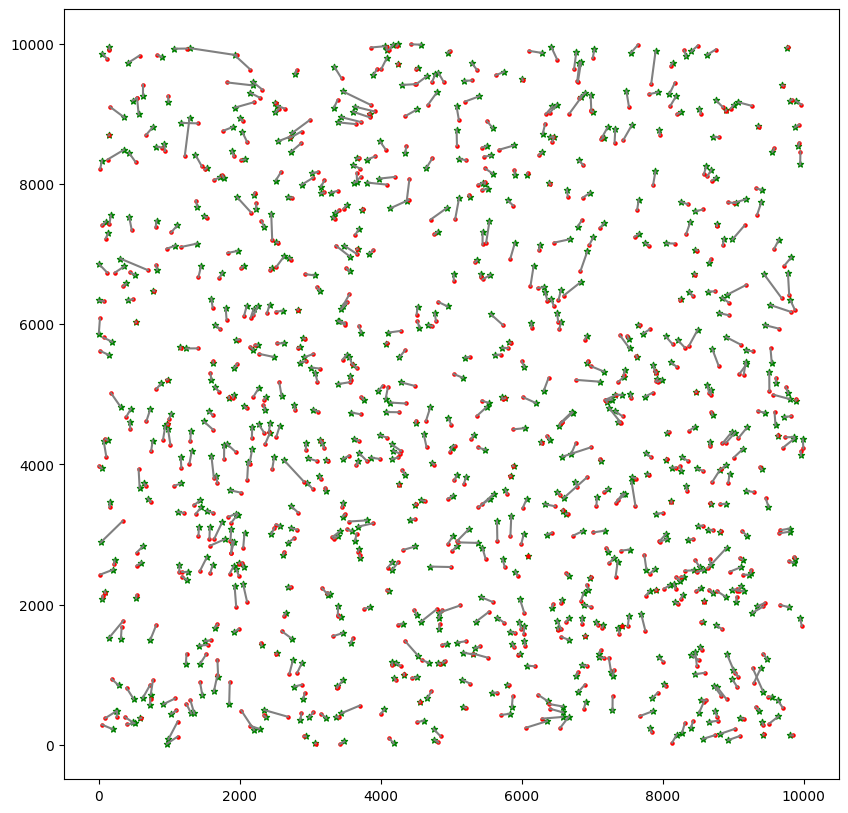

In [40]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


def get_color(i):
    # colors = list(matplotlib.colors.CSS4_COLORS.values())
    colors = matplotlib.cm.tab20.colors
    return colors[i % len(colors)]


point_inds = list(range(env.N))  # longs_points[:]
corrects_np = np.array(env.coordinates)[point_inds]
estimates_np = np.array(x_best)[point_inds]
rectangles = np.array([env.rectangles[i] for i in range(env.N)])[point_inds]

# 四角形と、四角形内の正解点と予測点を描画
plt.figure(figsize=(10, 10))
ax = plt.gca()
# for i, rect in enumerate(rectangles):
#     l, r, t, b = rect
#     ax.add_patch(matplotlib.patches.Rectangle((l, t), r - l, b - t, alpha=0.1))
ax.scatter(corrects_np[:, 0], corrects_np[:, 1], color="green", label="correct", s=20, marker="*")
ax.scatter(estimates_np[:, 0], estimates_np[:, 1], color="red", label="estimate", s=5, marker="o")
for point_ind in range(len(corrects_np)):
    ax.plot(
        (corrects_np[point_ind, 0], estimates_np[point_ind, 0]),
        (corrects_np[point_ind, 1], estimates_np[point_ind, 1]),
        color="gray",
        label="correct path",
    )
plt.show()